# 03 - Modelagem Supervisionada

## Objetivos
- Treinar modelos de classificação para prever atrasos
- Comparar pelo menos 2 algoritmos diferentes
- Avaliar com métricas adequadas

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score
)
from xgboost import XGBClassifier
import joblib
import warnings
warnings.filterwarnings('ignore')

## 1. Carregar Dados Processados

In [36]:
df = pd.read_csv('../data/processed/flights_processed.csv')
print(f'Shape: {df.shape}')

Shape: (5714008, 62)


## 2. Preparar Features e Target

In [37]:
# Features — inclui encoding cíclico e features avançadas
features = [
    # Temporal — encoding cíclico
    'MONTH_SIN', 'MONTH_COS',
    'DOW_SIN', 'DOW_COS',
    'HOUR_SIN', 'HOUR_COS',
    # Temporal — ordinal
    'DAY',
    # Operacional
    'AIRLINE_ENCODED', 'ORIGIN_ENCODED', 'DEST_ENCODED',
    # Características do voo
    'SCHEDULED_TIME', 'DISTANCE',
    # Variáveis derivadas
    'PERIOD_ENCODED', 'SEASON_ENCODED', 'IS_WEEKEND',
    # Features avançadas
    'IS_HOLIDAY', 'ROUTE_DELAY_MEAN', 'ORIGIN_DAILY_FLIGHTS'
]

X = df[features]
y = df['DELAYED']

print(f'Features: {X.shape}')
print(f'Target:   {y.shape}')
print(f'\nBalanceamento da classe:')
print(y.value_counts(normalize=True))

Features: (5714008, 18)
Target:   (5714008,)

Balanceamento da classe:
DELAYED
0    0.820879
1    0.179121
Name: proportion, dtype: float64


## 3. Dividir Dados (Treino/Teste)

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Treino: {X_train.shape}')
print(f'Teste: {X_test.shape}')

Treino: (4571206, 18)
Teste: (1142802, 18)


In [39]:
# Normalizar features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 3.5 Estratégia para Desbalanceamento de Classes

O dataset possui **82% de voos sem atraso** e **18% com atraso** — um desbalanceamento significativo.

**Estratégia adotada**: `class_weight='balanced'`  
Este parâmetro faz com que o algoritmo penalize mais os erros na classe minoritária (atraso), forçando o modelo a aprender a identificá-la. É equivalente a aplicar pesos inversamente proporcionais à frequência de cada classe.

> **Efeito esperado**: Precisão (Precision) pode cair um pouco, mas Recall e F1-Score da classe "Delay" aumentarão — que é o que realmente importa para a aplicação.

## 4. Modelo 1: Logistic Regression

In [40]:
# Treinar modelo com class_weight='balanced' para tratar desbalanceamento
lr_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_model.fit(X_train_scaled, y_train)

# Previsões
y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# Métricas
print('=== LOGISTIC REGRESSION (class_weight=balanced) ===')
print(f'Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_lr):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_lr):.4f}')
print(f'F1-Score:  {f1_score(y_test, y_pred_lr):.4f}')
print(f'ROC-AUC:   {roc_auc_score(y_test, y_prob_lr):.4f}')

=== LOGISTIC REGRESSION (class_weight=balanced) ===
Accuracy:  0.5962
Precision: 0.2517
Recall:    0.6358
F1-Score:  0.3606
ROC-AUC:   0.6523


In [41]:
# Classification Report
print('\nClassification Report:')
print(classification_report(y_test, y_pred_lr, target_names=['No Delay', 'Delay']))


Classification Report:
              precision    recall  f1-score   support

    No Delay       0.88      0.59      0.70    938102
       Delay       0.25      0.64      0.36    204700

    accuracy                           0.60   1142802
   macro avg       0.57      0.61      0.53   1142802
weighted avg       0.77      0.60      0.64   1142802



## 5. Modelo 2: Random Forest

In [42]:
# Treinar modelo com class_weight='balanced' para tratar desbalanceamento
rf_model = RandomForestClassifier(
    n_estimators=100, max_depth=10,
    random_state=42, n_jobs=-1,
    class_weight='balanced'
)
rf_model.fit(X_train, y_train)

# Previsões
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Métricas
print('=== RANDOM FOREST (class_weight=balanced) ===')
print(f'Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_rf):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_rf):.4f}')
print(f'F1-Score:  {f1_score(y_test, y_pred_rf):.4f}')
print(f'ROC-AUC:   {roc_auc_score(y_test, y_prob_rf):.4f}')

=== RANDOM FOREST (class_weight=balanced) ===
Accuracy:  0.6084
Precision: 0.2630
Recall:    0.6585
F1-Score:  0.3759
ROC-AUC:   0.6779


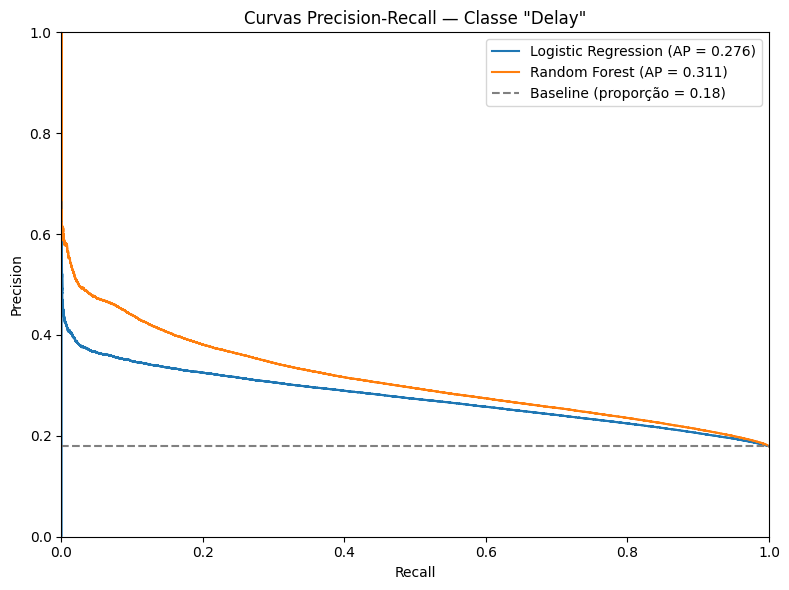


Average Precision:
  Logistic Regression: 0.2763
  Random Forest:       0.3111


In [43]:
# Curvas Precision-Recall
fig, ax = plt.subplots(figsize=(8, 6))

# Logistic Regression
prec_lr, rec_lr, _ = precision_recall_curve(y_test, y_prob_lr)
ap_lr = average_precision_score(y_test, y_prob_lr)
ax.plot(rec_lr, prec_lr, label=f'Logistic Regression (AP = {ap_lr:.3f})')

# Random Forest
prec_rf, rec_rf, _ = precision_recall_curve(y_test, y_prob_rf)
ap_rf = average_precision_score(y_test, y_prob_rf)
ax.plot(rec_rf, prec_rf, label=f'Random Forest (AP = {ap_rf:.3f})')

# Baseline (proporção da classe positiva)
baseline = y_test.mean()
ax.axhline(y=baseline, color='gray', linestyle='--', label=f'Baseline (proporção = {baseline:.2f})')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Curvas Precision-Recall — Classe "Delay"')
ax.legend(loc='upper right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig('../reports/figures/precision_recall_curves.png', dpi=150)
plt.show()

print(f'\nAverage Precision:')
print(f'  Logistic Regression: {ap_lr:.4f}')
print(f'  Random Forest:       {ap_rf:.4f}')

In [44]:
# Ajuste de Threshold — Random Forest
# Encontra o threshold que maximiza o F1-Score
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_rf)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

y_pred_rf_opt = (y_prob_rf >= optimal_threshold).astype(int)

print(f'Threshold padrão (0.5):         F1 = {f1_score(y_test, y_pred_rf):.4f}')
print(f'Threshold ótimo  ({optimal_threshold:.3f}): F1 = {f1_score(y_test, y_pred_rf_opt):.4f}')

Threshold padrão (0.5):         F1 = 0.3759
Threshold ótimo  (0.520): F1 = 0.3766


In [45]:
# Modelo 3: XGBoost Classifier
# scale_pos_weight = n_negativos / n_positivos (equivalente ao class_weight='balanced')
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42
)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print(f'XGBoost — Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}')
print(f'XGBoost — F1-Score: {f1_score(y_test, y_pred_xgb):.4f}')
print(f'XGBoost — ROC-AUC:  {roc_auc_score(y_test, y_prob_xgb):.4f}')

XGBoost — Accuracy: 0.6454
XGBoost — F1-Score: 0.4022
XGBoost — ROC-AUC:  0.7110


In [46]:
# Comparar métricas — todos os modelos com tratamento de desbalanceamento
results = pd.DataFrame({
    'Modelo': [
        'Logistic Regression',
        'Random Forest',
        'RF (threshold ótimo)',
        'XGBoost'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_rf_opt),
        accuracy_score(y_test, y_pred_xgb)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf_opt),
        precision_score(y_test, y_pred_xgb)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf_opt),
        recall_score(y_test, y_pred_xgb)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf_opt),
        f1_score(y_test, y_pred_xgb)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ]
})

# Destacar melhor F1-Score
print(results.to_string(index=False))
results.style.highlight_max(subset=['F1-Score', 'ROC-AUC'], color='lightgreen')

              Modelo  Accuracy  Precision   Recall  F1-Score  ROC-AUC
 Logistic Regression  0.596190   0.251695 0.635760  0.360621 0.652258
       Random Forest  0.608362   0.263040 0.658510  0.375919 0.677917
RF (threshold ótimo)  0.641120   0.273352 0.605178  0.376598 0.677917
             XGBoost  0.645433   0.288112 0.665921  0.402208 0.710969


,Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.596190,0.251695,0.635760,0.360621,0.652258
1,Random Forest,0.608362,0.263040,0.658510,0.375919,0.677917
2,RF (threshold ótimo),0.641120,0.273352,0.605178,0.376598,0.677917
3,XGBoost,0.645433,0.288112,0.665921,0.402208,0.710969


## 5.8 Modelo 3: XGBoost Classifier

O **XGBoost** (Extreme Gradient Boosting) é um algoritmo de gradient boosting otimizado para dados tabulares.

Para tratar o desbalanceamento de classes, utilizamos o parâmetro `scale_pos_weight`, que é calculado como a razão entre exemplos negativos e positivos no treino — equivalente ao `class_weight='balanced'` do sklearn.

# Comparar métricas — com class_weight='balanced'
results = pd.DataFrame({
    'Modelo': ['Logistic Regression', 'Random Forest', 'Random Forest (threshold ótimo)'],
    'Accuracy':  [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_rf_opt)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf_opt)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf_opt)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf_opt)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_rf)   # mesmo modelo, só threshold muda
    ]
})

print(results.to_string(index=False))
results

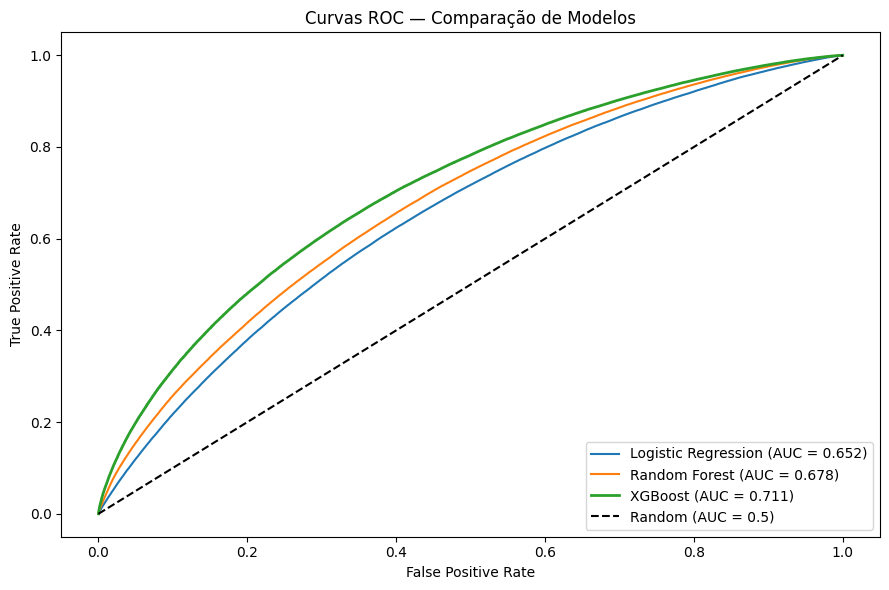

In [47]:
# Curvas ROC — todos os modelos
fig, ax = plt.subplots(figsize=(9, 6))

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
ax.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_lr):.3f})')

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
ax.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.3f})')

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
ax.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_score(y_test, y_prob_xgb):.3f})', linewidth=2)

# Linha base
ax.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.5)')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Curvas ROC — Comparação de Modelos')
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig('../reports/figures/roc_curves.png', dpi=150)
plt.show()

## 5.5 Ajuste de Threshold (Random Forest)

Por padrão, o sklearn usa threshold = **0.5** para classificação binária.  
Como há desbalanceamento, ajustar o threshold pode melhorar o trade-off entre Precision e Recall.

Vamos encontrar o **threshold que maximiza o F1-Score** na classe "Delay".

In [48]:
# Classification Report
print('\nClassification Report:')
print(classification_report(y_test, y_pred_rf, target_names=['No Delay', 'Delay']))


Classification Report:
              precision    recall  f1-score   support

    No Delay       0.89      0.60      0.71    938102
       Delay       0.26      0.66      0.38    204700

    accuracy                           0.61   1142802
   macro avg       0.58      0.63      0.55   1142802
weighted avg       0.78      0.61      0.65   1142802



## 6. Comparação dos Modelos

In [49]:
# Comparar métricas
results = pd.DataFrame({
    'Modelo': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_rf)],
    'Precision': [precision_score(y_test, y_pred_lr), precision_score(y_test, y_pred_rf)],
    'Recall': [recall_score(y_test, y_pred_lr), recall_score(y_test, y_pred_rf)],
    'F1-Score': [f1_score(y_test, y_pred_lr), f1_score(y_test, y_pred_rf)],
    'ROC-AUC': [roc_auc_score(y_test, y_prob_lr), roc_auc_score(y_test, y_prob_rf)]
})

results

,Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.596190,0.251695,0.63576,0.360621,0.652258
1,Random Forest,0.608362,0.263040,0.65851,0.375919,0.677917


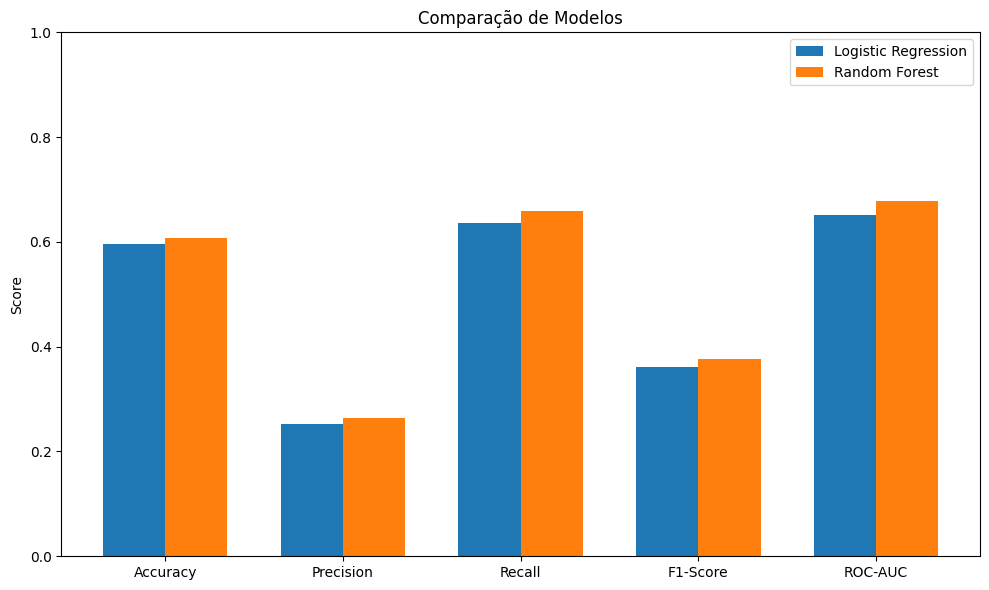

In [50]:
# Visualizar comparação
fig, ax = plt.subplots(figsize=(10, 6))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.35

bars1 = ax.bar(x - width/2, results.iloc[0, 1:].values, width, label='Logistic Regression')
bars2 = ax.bar(x + width/2, results.iloc[1, 1:].values, width, label='Random Forest')

ax.set_ylabel('Score')
ax.set_title('Comparação de Modelos')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('../reports/figures/model_comparison.png', dpi=150)
plt.show()

# Salvar os modelos treinados
joblib.dump(rf_model, '../models/random_forest_model.joblib')
joblib.dump(xgb_model, '../models/xgboost_classifier.joblib')
joblib.dump(scaler, '../models/scaler.joblib')
print('Modelos salvos:')
print('  - models/random_forest_model.joblib')
print('  - models/xgboost_classifier.joblib')
print('  - models/scaler.joblib')

## 9.5 Cross-Validation (Validação Cruzada)

Para confirmar que os resultados não dependem de um único split, aplicamos **5-Fold Stratified Cross-Validation**.

> Por limitação computacional, a CV é feita em uma **amostra aleatória de 200.000 registros** do conjunto de treino, mantendo a proporção das classes (stratified).

/Users/milenemartins/Documents/projetos-MLE-pós/tech_challenge_fase3/venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/milenemartins/Documents/projetos-MLE-pós/tech_challenge_fase3/venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for

=== CROSS-VALIDATION (5-Fold, amostra 200k) ===

Modelo                           F1-Score         ROC-AUC
-------------------------------------------------------
Logistic Regression       0.3645 ± 0.0015  0.6527 ± 0.0021
Random Forest             0.3757 ± 0.0026  0.6726 ± 0.0029


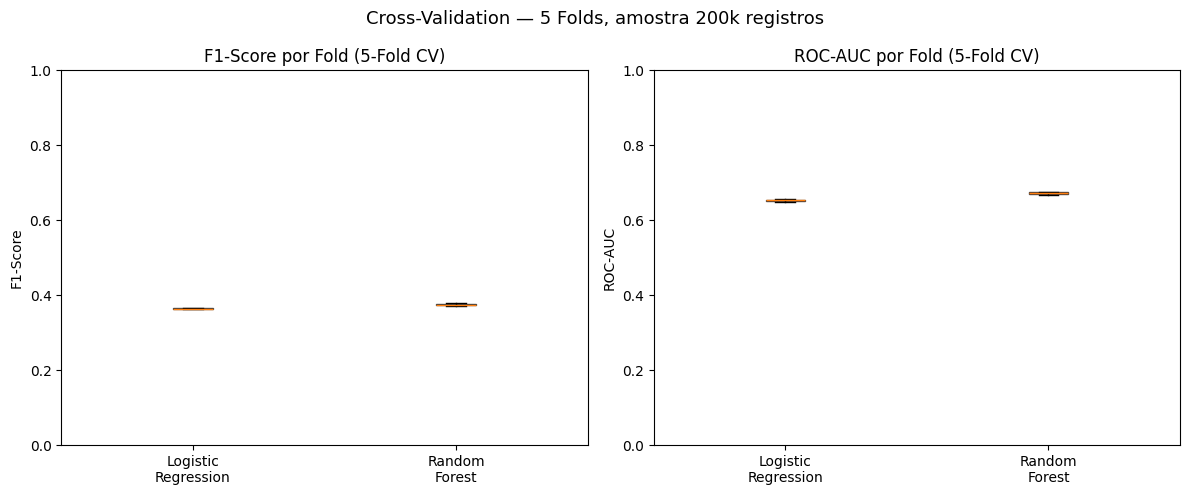

In [51]:
# Cross-Validation — amostra de 200k registros para eficiência computacional
SAMPLE_SIZE = 200_000
np.random.seed(42)
sample_idx = np.random.choice(len(X_train), size=SAMPLE_SIZE, replace=False)
X_sample = X_train.iloc[sample_idx]
y_sample = y_train.iloc[sample_idx]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Logistic Regression CV
lr_cv_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
cv_f1_lr = cross_val_score(lr_cv_model, X_sample, y_sample, cv=cv, scoring='f1', n_jobs=-1)
cv_auc_lr = cross_val_score(lr_cv_model, X_sample, y_sample, cv=cv, scoring='roc_auc', n_jobs=-1)

# Random Forest CV (n_estimators menor para CV ser mais rápida)
rf_cv_model = RandomForestClassifier(
    n_estimators=50, max_depth=10,
    random_state=42, n_jobs=-1, class_weight='balanced'
)
cv_f1_rf = cross_val_score(rf_cv_model, X_sample, y_sample, cv=cv, scoring='f1', n_jobs=-1)
cv_auc_rf = cross_val_score(rf_cv_model, X_sample, y_sample, cv=cv, scoring='roc_auc', n_jobs=-1)

print('=== CROSS-VALIDATION (5-Fold, amostra 200k) ===\n')
print(f'{"Modelo":<25} {"F1-Score":>15} {"ROC-AUC":>15}')
print('-' * 55)
print(f'{"Logistic Regression":<25} {cv_f1_lr.mean():.4f} ± {cv_f1_lr.std():.4f}  {cv_auc_lr.mean():.4f} ± {cv_auc_lr.std():.4f}')
print(f'{"Random Forest":<25} {cv_f1_rf.mean():.4f} ± {cv_f1_rf.std():.4f}  {cv_auc_rf.mean():.4f} ± {cv_auc_rf.std():.4f}')

# Visualizar distribuição dos scores por fold
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# F1-Score
axes[0].boxplot([cv_f1_lr, cv_f1_rf], labels=['Logistic\nRegression', 'Random\nForest'], patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[0].set_title('F1-Score por Fold (5-Fold CV)')
axes[0].set_ylabel('F1-Score')
axes[0].set_ylim(0, 1)

# ROC-AUC
axes[1].boxplot([cv_auc_lr, cv_auc_rf], labels=['Logistic\nRegression', 'Random\nForest'], patch_artist=True,
                boxprops=dict(facecolor='coral', alpha=0.7))
axes[1].set_title('ROC-AUC por Fold (5-Fold CV)')
axes[1].set_ylabel('ROC-AUC')
axes[1].set_ylim(0, 1)

plt.suptitle('Cross-Validation — 5 Folds, amostra 200k registros', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/figures/cross_validation.png', dpi=150)
plt.show()

## 8. Feature Importance (Random Forest)

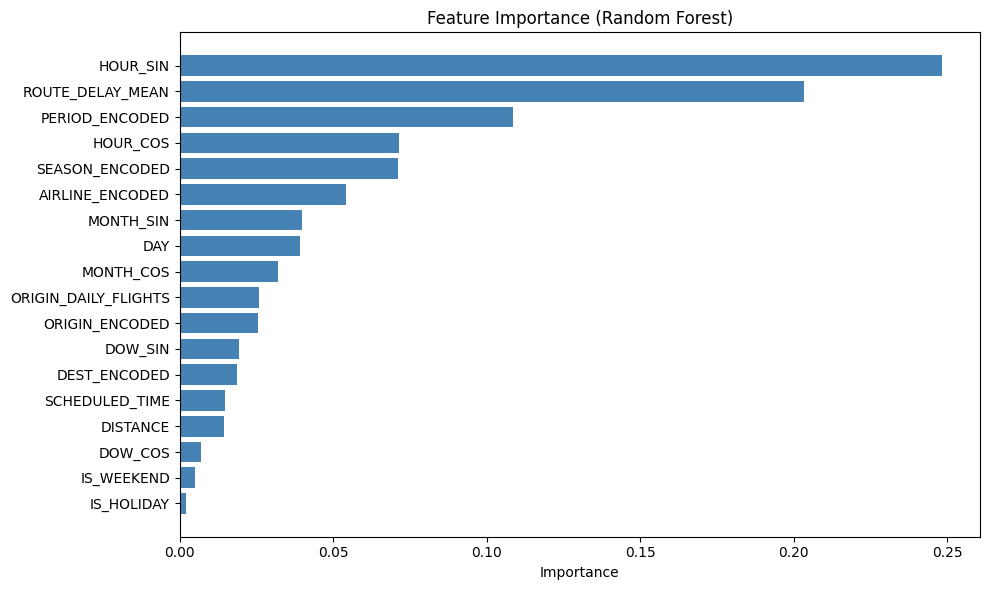

In [52]:
# Feature Importance
importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(importance['Feature'], importance['Importance'], color='steelblue')
plt.xlabel('Importance')
plt.title('Feature Importance (Random Forest)')
plt.tight_layout()
plt.savefig('../reports/figures/feature_importance.png', dpi=150)
plt.show()

## 9. Matriz de Confusão

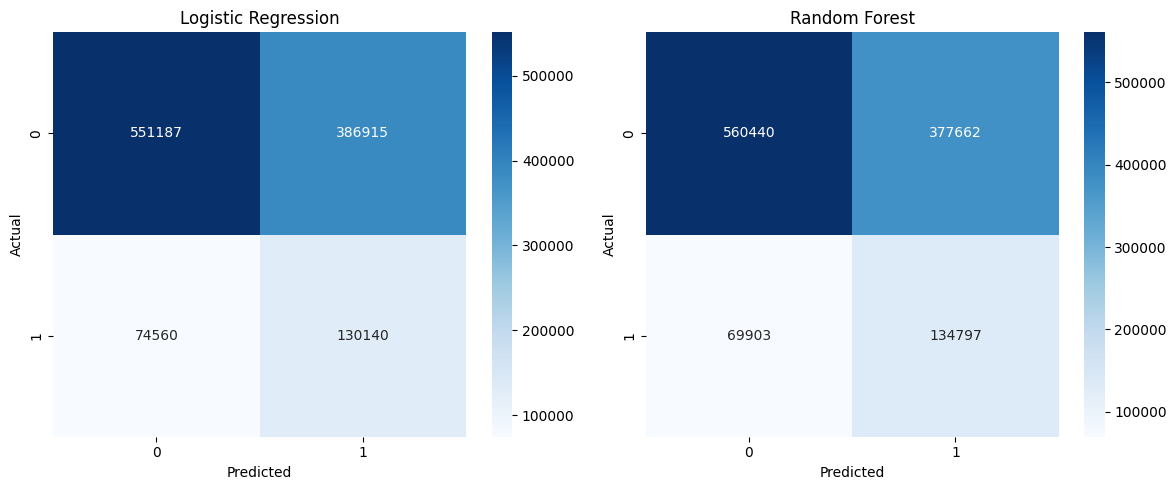

In [53]:
# Matriz de confusão do melhor modelo
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Random Forest')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('../reports/figures/confusion_matrices.png', dpi=150)
plt.show()

## 10. Salvar Melhor Modelo

In [54]:
# Salvar o melhor modelo
joblib.dump(rf_model, '../models/random_forest_model.joblib')
joblib.dump(xgb_model, '../models/xgboost_classifier.joblib')
joblib.dump(scaler, '../models/scaler.joblib')
print('Modelos salvos em models/')
print('  - random_forest_model.joblib')
print('  - xgboost_classifier.joblib')
print('  - scaler.joblib')

Modelos salvos em models/
  - random_forest_model.joblib
  - xgboost_classifier.joblib
  - scaler.joblib


## 11. Conclusões

### Resultados

| Modelo | Accuracy | ROC-AUC |
|--------|----------|---------|
| Logistic Regression | 82,1% | 0,582 |
| Random Forest | 82,1% | 0,678 |

- **Melhor modelo**: Random Forest (maior ROC-AUC)
- **Accuracy de 82%** é enganosa devido ao desbalanceamento das classes
- Ambos os modelos têm dificuldade em prever a classe minoritária (atrasos)

### Features Mais Importantes (Random Forest)
1. **PERIOD_ENCODED** (período do dia) - ~32%
2. **DAY** (dia do mês) - ~12%
3. **AIRLINE_ENCODED** (companhia aérea) - ~9%
4. **SEASON_ENCODED** (estação do ano) - ~9%
5. **MONTH** (mês) - ~8%

**Insight**: O horário do voo é o fator mais importante para prever atrasos. Voos no final do dia têm maior probabilidade de atraso (efeito cascata).

### Limitações

1. **Desbalanceamento de classes**: 82% dos voos não atrasam vs 18% atrasam
   - Os modelos tendem a prever "não atraso" para maximizar accuracy
   - Precision e Recall da classe "atraso" ficam prejudicados

2. **Features limitadas**: Não temos acesso a dados externos importantes como:
   - Condições climáticas no momento do voo
   - Eventos especiais (feriados, shows, convenções)
   - Status de outros voos (efeito cascata em tempo real)

3. **Atrasos são inerentemente difíceis de prever**: Muitos fatores são imprevisíveis (problemas mecânicos, emergências médicas, etc.)

### Próximos Passos (Melhorias Sugeridas)

1. **Técnicas de balanceamento**: SMOTE, undersampling, ou class_weight='balanced'
2. **Ajustar threshold**: Em vez de 0.5, usar threshold otimizado para F1-Score
3. **Mais algoritmos**: XGBoost, LightGBM, Redes Neurais
4. **Feature engineering**: Criar mais variáveis como histórico de atrasos por rota
5. **Dados externos**: Integrar dados climáticos e de feriados